## K-Nearest Neighbour Graphs 

First we create a fake data set and build the KNN graph 

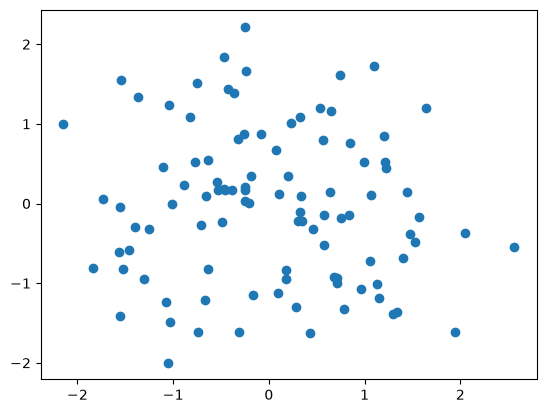

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

N = 100
X = np.random.randn(N, 2)

# plotting 
plt.scatter(X[:, 0], X[:, 1])
plt.show()

### Define the distance metric

In [3]:
# define the distance metric : L2 distance 

def euclid(x, y): 
    # x and y both are vectors here
    return np.linalg.norm(x-y)

In [9]:
# testing the above function 
print(euclid(X[0], X[1]))
# import math 
# print(math.sqrt((X[0,0]-X[1,0])**2 + (X[0,1]-X[1,1])**2))

2.2942514887501626


### The function to find KNNs

In [48]:
def get_knn(X, i, k):
    '''
    X : data matrix containing vectors 
    i : the index of the vector whose K nearest neighbours we search 
    k : hyperparameter
    '''
    distances = []

    for j in range(len(X)):
        if i == j:
            continue

        d = euclid(X[i], X[j])
        distances.append((d, j))

    distances.sort()

    return [j for _, j in distances[:k]]

In [49]:
output = get_knn(X, 0, 3)
X[output]

array([[-0.63968351, -0.82666167],
       [-1.07664286, -1.23056944],
       [-0.74445458, -1.6191711 ]])

### Building a KNN Graph

In [122]:
def build_knn_graph(X, k): 
    graph = {}
    
    for i in range(len(X)): 
        graph[i] = get_knn(X, i, k)
    
    return graph 

In [123]:
g = build_knn_graph(X,3)
print(g)

{0: [95, 52, 27], 1: [22, 51, 3], 2: [99, 63, 45], 3: [22, 1, 44], 4: [90, 75, 71], 5: [21, 83, 75], 6: [71, 88, 37], 7: [50, 35, 28], 8: [47, 2, 29], 9: [12, 59, 57], 10: [69, 54, 80], 11: [98, 62, 97], 12: [17, 15, 9], 13: [10, 69, 54], 14: [76, 70, 33], 15: [17, 12, 33], 16: [42, 83, 26], 17: [15, 12, 33], 18: [81, 37, 89], 19: [94, 86, 82], 20: [51, 96, 67], 21: [5, 75, 4], 22: [1, 3, 51], 23: [43, 60, 66], 24: [56, 78, 73], 25: [33, 70, 14], 26: [82, 86, 16], 27: [84, 0, 46], 28: [35, 50, 7], 29: [87, 8, 68], 30: [38, 85, 97], 31: [42, 16, 26], 32: [90, 39, 4], 33: [15, 17, 70], 34: [50, 79, 35], 35: [28, 50, 34], 36: [88, 6, 71], 37: [81, 18, 6], 38: [30, 97, 11], 39: [40, 90, 19], 40: [39, 19, 94], 41: [18, 81, 37], 42: [16, 26, 31], 43: [60, 23, 66], 44: [80, 3, 66], 45: [72, 63, 2], 46: [27, 7, 0], 47: [8, 2, 99], 48: [83, 16, 42], 49: [55, 62, 11], 50: [35, 34, 7], 51: [1, 22, 20], 52: [84, 89, 0], 53: [52, 84, 89], 54: [80, 66, 69], 55: [62, 11, 97], 56: [78, 24, 73], 57: [5

### Visualizing the Graph

In [124]:
# Visualizing the graph 
def plot_graph(X, graph):
    plt.figure(figsize=(10, 10))

    # Draw points
    plt.scatter(X[:, 0], X[:, 1])

    # Draw edges
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.5
            )

    plt.show()

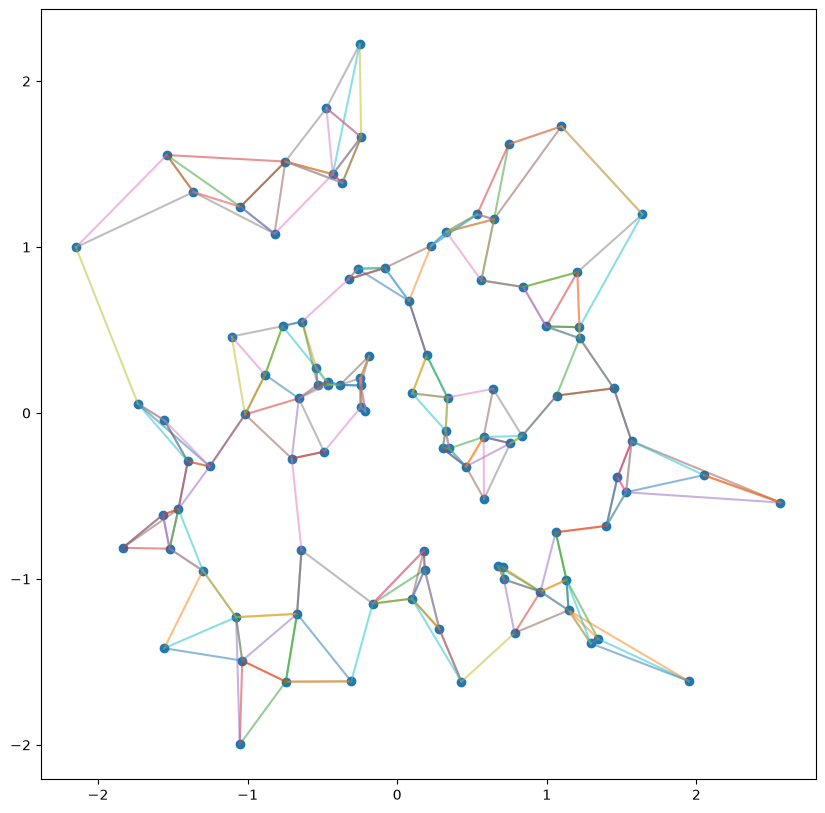

In [125]:
plot_graph(X, g)

### Implementing Greedy Search

In [126]:
def greedy_search(X, graph, query, start): 
    current = start 
    path = [current]
    # steps = 0 
    
    while True: 
        # # just a safety check 
        # if steps > 100: 
        #     break 
        
        neighbours = graph[current]
        current_dist = euclid(X[current], query)
        best_choice = []
        
        for n in neighbours: 
            d = euclid(query, X[n])
            if d  < current_dist: 
                best_choice.append((n, d)) 
        
        if best_choice == []: 
            # local minium 
            break
        else: 
            best_choice.sort(key=lambda t : t[1])
            current = best_choice[0][0]
            path.append(current)
        
        # steps += 1   
    
    return current, path

In [127]:
query = np.array([1.5, 1.5])

result, path = greedy_search(
    X,
    g,
    query,
    start=0
)

print("Graph result:", result)
print("Point:", X[result])

Graph result: 31
Point: [-0.18789302  0.34297517]


### Printing the path followed by the Greedy Search

In [128]:
print(path)

[0, 95, 21, 75, 86, 26, 16, 42, 31]


In [129]:
def exact_search(X, query):
    distances = np.linalg.norm(X - query, axis=1)
    return np.argmin(distances)

print(exact_search(X, query))

29


In [130]:
def plot_search(X, graph, query, path):

    plt.figure(figsize=(10, 10))

    # Graph
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.08
            )

    # All points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        alpha=0.5
    )

    # Query
    plt.scatter(
        query[0],
        query[1],
        marker="*",
        s=250, 
        label = 'query'
    )

    plt.scatter(
        X[path[0]][0],
        X[path[0]][1], 
        marker = '.', 
        s = 350, 
        c = 'r', 
        label='start-point'
    )
    
    # Search path
    for a, b in zip(path[:-1], path[1:]):
        plt.plot(
            [X[a, 0], X[b, 0]],
            [X[a, 1], X[b, 1]],
            linewidth=3,
        )
        
    plt.legend()    
    plt.show()
    

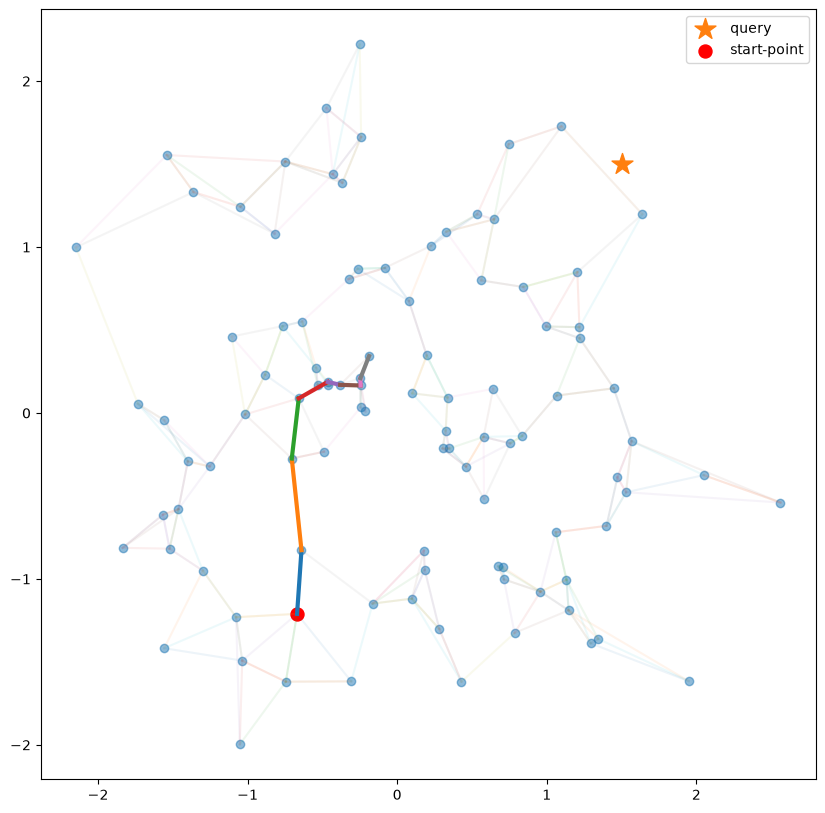

In [131]:
plot_search(X, g, query, path)

In [133]:
for k in [2, 4, 8, 16, 32]:

    graph = build_knn_graph(X, k)

    correct = 0
    total_steps = 0

    for _ in range(1000):

        query = np.random.randn(2)

        exact = exact_search(X, query)

        result, path = greedy_search(
            X,
            graph,
            query,
            start=0
        )

        if result == exact:
            correct += 1

        total_steps += len(path)

    print(
        f"k={k:2d} | "
        f"recall={correct/1000:.3f} | "
        f"avg steps={total_steps/1000:.2f}"
    )

k= 2 | recall=0.157 | avg steps=4.29
k= 4 | recall=0.335 | avg steps=4.68
k= 8 | recall=0.815 | avg steps=4.93
k=16 | recall=0.999 | avg steps=3.65
k=32 | recall=1.000 | avg steps=2.93
